# Football IQ - Real-Time Sentiment Tracker




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

PROCESSED = "data/processed/"


## 1. Load cleaned tweets and (re)train the classifier

In [4]:
wc_tweets = pd.read_csv(PROCESSED + "clean_wc_tweets.csv", parse_dates=['Date Created'])
print(wc_tweets.shape)
wc_tweets.head(3)


(22524, 7)


,Unnamed: 0,Date Created,Number of Likes,Source of Tweet,Tweet,Sentiment,clean_text
0,0,2022-11-20 23:59:21+00:00,4,Twitter Web App,What are we drinking today @TucanTribe \n@MadB...,neutral,What are we drinking today WorldCup2022
1,1,2022-11-20 23:59:01+00:00,3,Twitter for iPhone,Amazing @CanadaSoccerEN #WorldCup2022 launch ...,positive,Amazing WorldCup2022 launch video. Shows how m...
2,2,2022-11-20 23:58:41+00:00,1,Twitter for iPhone,Worth reading while watching #WorldCup2022 htt...,positive,Worth reading while watching WorldCup2022


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    wc_tweets['clean_text'], wc_tweets['Sentiment'], test_size=0.2, random_state=42, stratify=wc_tweets['Sentiment']
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train_vec, y_train)

test_preds = clf.predict(X_test_vec)
print(f"Held-out test accuracy: {(test_preds==y_test).mean():.1%}")
print(classification_report(y_test, test_preds))


Held-out test accuracy: 71.6%
              precision    recall  f1-score   support

    negative       0.66      0.77      0.71      1157
     neutral       0.70      0.66      0.68      1650
    positive       0.78      0.73      0.76      1698

    accuracy                           0.72      4505
   macro avg       0.71      0.72      0.72      4505
weighted avg       0.72      0.72      0.72      4505



## 2. Score every tweet and bucket by minute

In [7]:
wc_tweets['predicted_sentiment'] = clf.predict(tfidf.transform(wc_tweets['clean_text']))
wc_tweets['sentiment_score'] = wc_tweets['predicted_sentiment'].map({'positive':1, 'neutral':0, 'negative':-1})

# Kickoff was 16:00 UTC. Bucket into 5-minute windows across the match.
wc_tweets['minutes_from_kickoff'] = (wc_tweets['Date Created'] - pd.Timestamp('2022-11-20 16:00:00', tz='UTC')).dt.total_seconds() / 60

match_window = wc_tweets[(wc_tweets['minutes_from_kickoff'] >= -15) & (wc_tweets['minutes_from_kickoff'] <= 110)].copy()
match_window['minute_bucket'] = (match_window['minutes_from_kickoff'] // 5) * 5

timeline = match_window.groupby('minute_bucket').agg(
    tweet_volume=('sentiment_score','count'),
    avg_sentiment=('sentiment_score','mean'),
).reset_index()

print(f"{len(match_window)} tweets in the match window ({match_window['minute_bucket'].min():.0f} to {match_window['minute_bucket'].max():.0f} min from kickoff)")
timeline.head()


9741 tweets in the match window (-15 to 110 min from kickoff)


,minute_bucket,tweet_volume,avg_sentiment
0,-15.0,296,0.256757
1,-10.0,316,0.275316
2,-5.0,520,0.330769
3,0.0,643,0.349922
4,5.0,2169,-0.362379


## 3. Sentiment shift across the match timeline



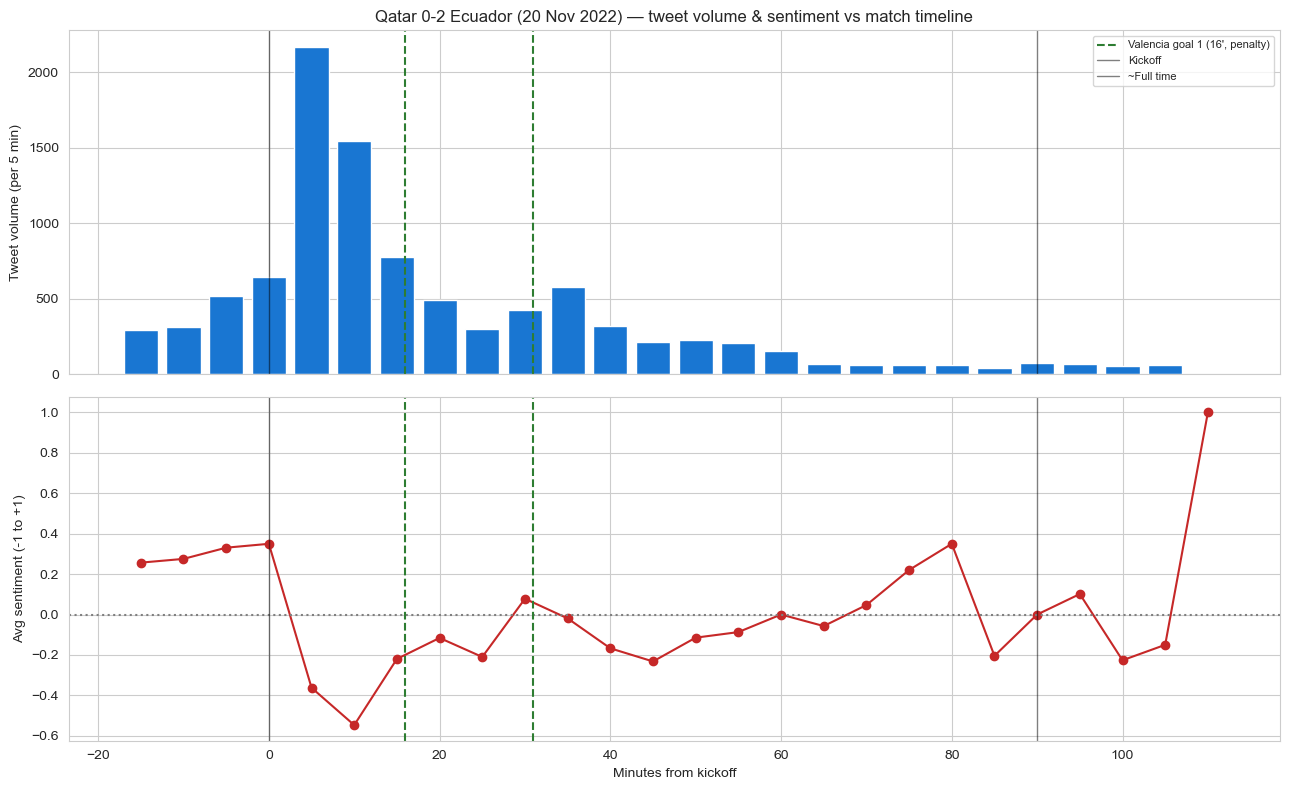

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13,8), sharex=True)

axes[0].bar(timeline['minute_bucket'], timeline['tweet_volume'], width=4, color='#1976d2')
axes[0].set_ylabel('Tweet volume (per 5 min)')
axes[0].set_title('Qatar 0-2 Ecuador (20 Nov 2022) — tweet volume & sentiment vs match timeline')

axes[1].plot(timeline['minute_bucket'], timeline['avg_sentiment'], marker='o', color='#c62828')
axes[1].axhline(0, color='grey', linestyle=':')
axes[1].set_ylabel('Avg sentiment (-1 to +1)')
axes[1].set_xlabel("Minutes from kickoff")

for ax in axes:
    ax.axvline(16, color='#2e7d32', linestyle='--', label="Valencia goal 1 (16', penalty)")
    ax.axvline(31, color='#2e7d32', linestyle='--')
    ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5, label='Kickoff')
    ax.axvline(90, color='black', linestyle='-', linewidth=1, alpha=0.5, label='~Full time')

axes[0].legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()


## 4. Overall sentiment distribution 

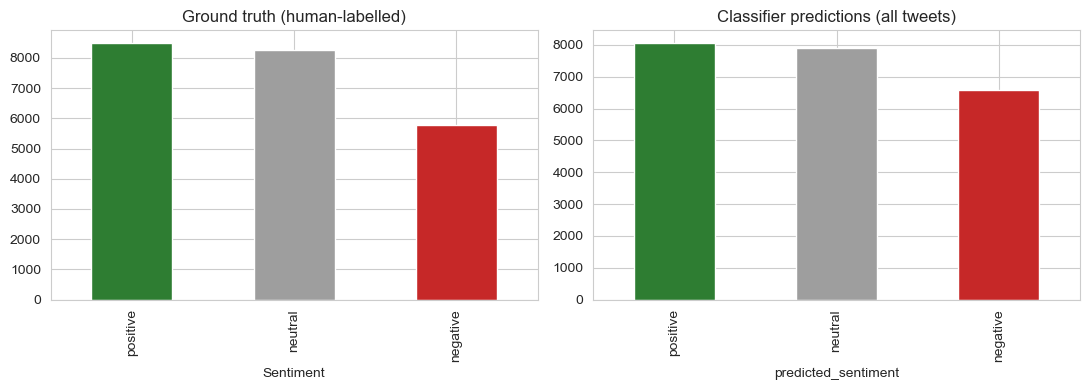

In [12]:
fig, axes = plt.subplots(1,2, figsize=(11,4))
wc_tweets['Sentiment'].value_counts().reindex(['positive','neutral','negative']).plot(
    kind='bar', ax=axes[0], color=['#2e7d32','#9e9e9e','#c62828'])
axes[0].set_title('Ground truth (human-labelled)')

wc_tweets['predicted_sentiment'].value_counts().reindex(['positive','neutral','negative']).plot(
    kind='bar', ax=axes[1], color=['#2e7d32','#9e9e9e','#c62828'])
axes[1].set_title('Classifier predictions (all tweets)')
plt.tight_layout()
plt.show()


## 5. Apply to FPL tweets (larger, unlabelled, ongoing volume — not tied to a single match)



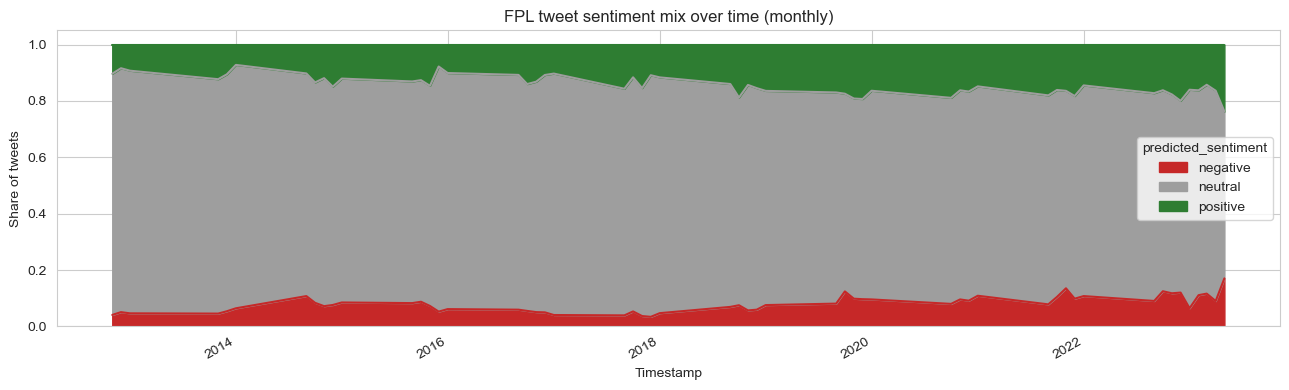

In [14]:
fpl_tweets = pd.read_csv(PROCESSED + "clean_fpl_tweets.csv", parse_dates=['Timestamp'])
fpl_tweets['predicted_sentiment'] = clf.predict(tfidf.transform(fpl_tweets['clean_text'].fillna('')))

fpl_monthly = fpl_tweets.set_index('Timestamp').groupby([pd.Grouper(freq='ME'), 'predicted_sentiment']).size().unstack(fill_value=0)
fpl_monthly_pct = fpl_monthly.div(fpl_monthly.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(13,4))
fpl_monthly_pct.plot(kind='area', stacked=True, ax=ax, color=['#c62828','#9e9e9e','#2e7d32'])
ax.set_title('FPL tweet sentiment mix over time (monthly)')
ax.set_ylabel('Share of tweets')
plt.tight_layout()
plt.show()


## 6. Summary


